# Art Gallery Problem

In [1]:
import os
import torch
import numpy as np

from skgeom import *
from skgeom.draw import draw

import matplotlib.pyplot as plt
from pathlib import Path

import pandas as pd

from typing   import Tuple


from data_types import VisSample 
from evaluate   import polygon_demo

Reading Art Gallery instances in the same format as Terrain Guarding instances.

## Dataset description 

convert art  gallery instance files to terrain guarding instance files

In [2]:
dataset_desc = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2009a-simplerand.csv'

               
with open(dataset_desc,'r') as csv_file:
    df = pd.read_csv(csv_file,delimiter=' ')
    
df   

,instance,vertices,strategy,iterations,guards,preProcTime(s),procTime(s),totalTime(s)
0,randsimple-20-17,20,All Vertices,2,3,0.06,0.01,0.07
1,randsimple-20-30,20,All Vertices,3,3,0.06,0.02,0.07
2,randsimple-20-25,20,All Vertices,2,4,0.06,0.02,0.07
3,randsimple-20-24,20,All Vertices,1,3,0.06,0.01,0.06
4,randsimple-20-26,20,All Vertices,1,3,0.05,0.01,0.06
...,...,...,...,...,...,...,...,...
2395,randsimple-2500-17,2500,Single Vertex,57,343,660.83,481.98,1142.81
2396,randsimple-2500-15,2500,Single Vertex,48,346,666.56,482.18,1148.74
2397,randsimple-2500-9,2500,Single Vertex,46,330,662.03,468.19,1130.22
2398,randsimple-2500-5,2500,Single Vertex,66,342,659.44,482.33,1141.76


# Model

In [3]:
# model
# availiable device
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

In [4]:
# folders
dataset_dir = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2009a-simplerand'
result_dir  = 'results/simplerand'
models_dir  = './trained_models/ag_ne-10_bs-4_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized' 

In [5]:
# latest
model_path = os.path.join(models_dir,'model_epoch_10.pt')

## Testing

In [6]:

from data_types import VisSample

instance = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2009a-simplerand/20/randsimple-20-1.pol'

samples = VisSample.read_samples(instance)
sample = samples[0]

sample.guards
sample

VisSample(name='randsimple-20-1', points=[tensor([0.3339, 0.2431, 0.0000]), tensor([0.4086, 0.1993, 0.0000]), tensor([0.3123, 0.1947, 0.0000]), tensor([0.0294, 0.2914, 0.0000]), tensor([0.5614, 0.0000, 0.0000]), tensor([0.5588, 0.0300, 0.0000]), tensor([0.6487, 0.1518, 0.0000]), tensor([0.9293, 0.2615, 0.0000]), tensor([0.9011, 0.4047, 0.0000]), tensor([0.4991, 0.4086, 0.0000]), tensor([0.3483, 0.5342, 0.0000]), tensor([1.0000, 0.5280, 0.0000]), tensor([0.7298, 0.5694, 0.0000]), tensor([0.1837, 0.5815, 0.0000]), tensor([0.3851, 0.3952, 0.0000]), tensor([0.7824, 0.3206, 0.0000]), tensor([0.5420, 0.1363, 0.0000]), tensor([0.3497, 0.3279, 0.0000]), tensor([0.3101, 0.3471, 0.0000]), tensor([0.0000, 0.4646, 0.0000])], guards=tensor([ 5, 13, 15, 19]))

# Demo

In [7]:
from data_types import VisSample

instance = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2009a-simplerand/40/randsimple-40-1.pol'

samples = VisSample.read_samples(instance)
sample = samples[0]



Predicting guards for art gallery.

In [8]:
from evaluate import polygon_demo
# model
model = torch.load(model_path)

In [9]:

poly,region, predicted, opt,coverage = polygon_demo(model,sample,beam_width=1,alpha=0.7)

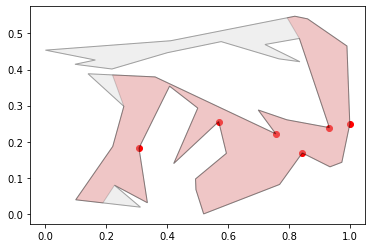

coverage : 0.7858505735267685


In [10]:
draw(poly,line_width=1,alpha=0.2,aspect_ratio = 'auto')     
draw(region,line_width=1,alpha=0.2,aspect_ratio = 'auto',facecolor = 'red')     
draw(predicted,color = 'red')

# opt
draw(poly,line_width=1,alpha=0.2,aspect_ratio = 'auto')        
#draw(self.opt,color = 'blue')
plt.show()

print(f"coverage : {coverage}")

PtrNet


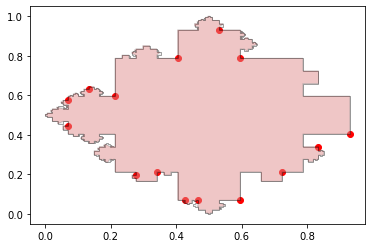

Optimal


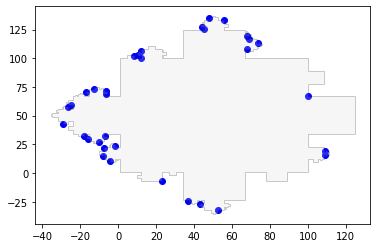

PtrNet coverage:     0.99729160,      ratio=pred/opt: 0.44117647


In [18]:
# data
from evaluate import AGNetSearch, Opt


dataset_dir = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2008a-rvk/500'
instances = ['']
instance = os.path.join(dataset_dir,'randvon-500-2.pol')

#opt value
opt = Opt()
# PTrNet search
ns = AGNetSearch(model_path)

# prediction
sol_opt    = opt.predict(instance)
sol_ns     = ns.predict(instance,beam_width=4,beta=0.000001)


print('PtrNet')
ns.show()
print('Optimal')
opt.show()


print(f'PtrNet coverage:     {ns.coverage:2.8f},      ratio=pred/opt: {len(sol_ns)/len(sol_opt):2.8f}')
